In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from import_folder import import_single_noiselevel_data, PQD_INDICES

# 1. Load Data
noiseless_data = import_single_noiselevel_data(r'SNR_noiseless')

# 2. Separate Features and Label
X = noiseless_data.drop(columns=['label'])
y = noiseless_data['label']

# 3. Train-Test Split (before scaling to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X.columns)

print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)

Training features shape: (1072, 8)
Testing features shape: (269, 8)


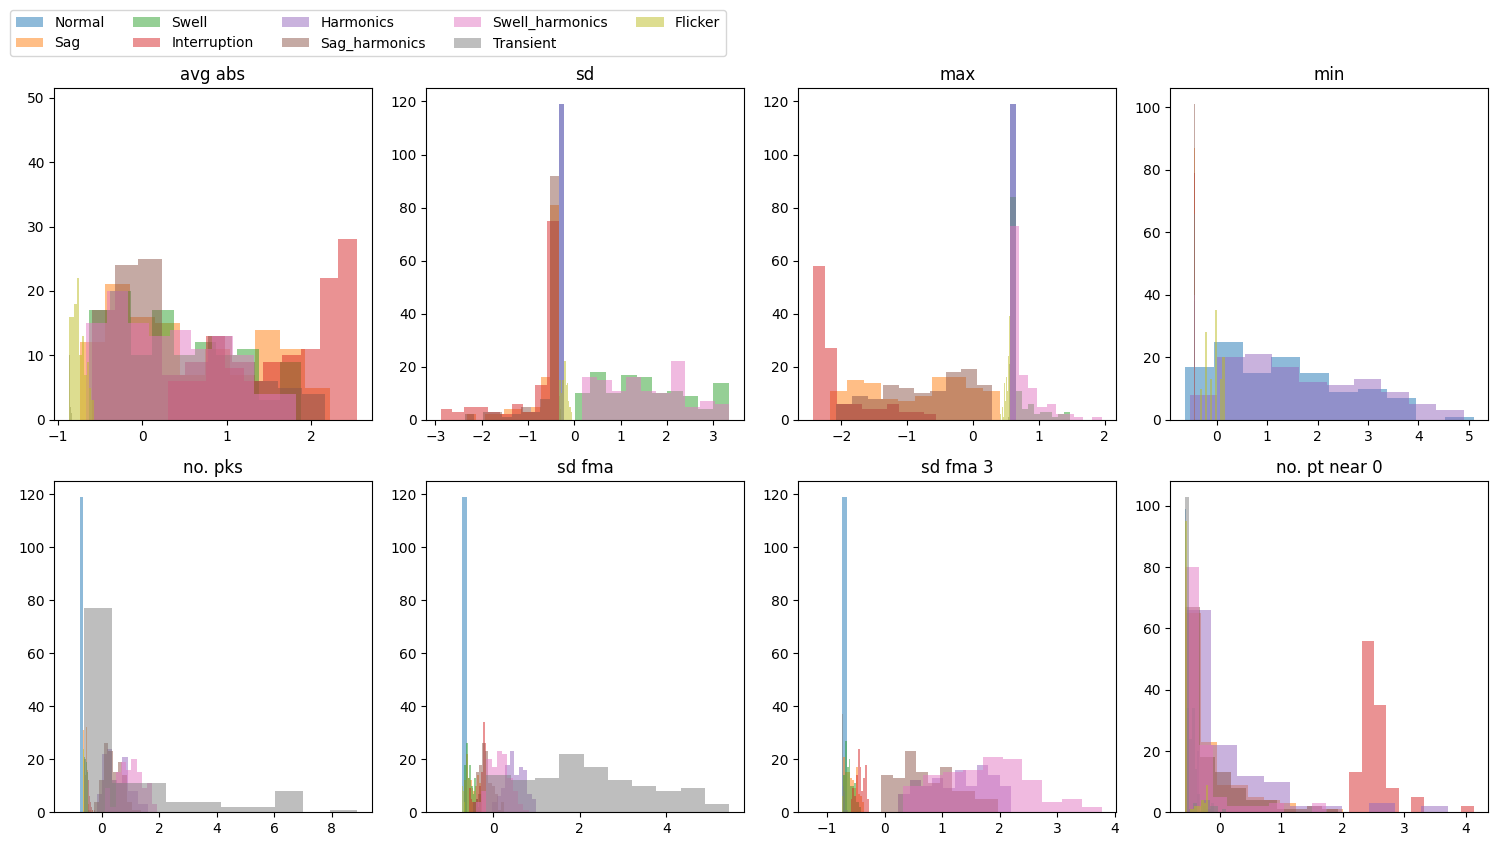

In [2]:
import matplotlib.pyplot as plt

# 8 subplots: Each subplot will shows the histogram distribution of a feature for each label
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(X_train_scaled.columns):
    for PQD, PQD_index in PQD_INDICES.items():
        axes[i].hist(X_train_scaled[y_train == PQD_index][feature], alpha=0.5, label=PQD)
    axes[i].set_title(feature)
# one legend outside the subplots on the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper left', ncol=5, bbox_to_anchor=(0, 1.06))
fig.tight_layout()


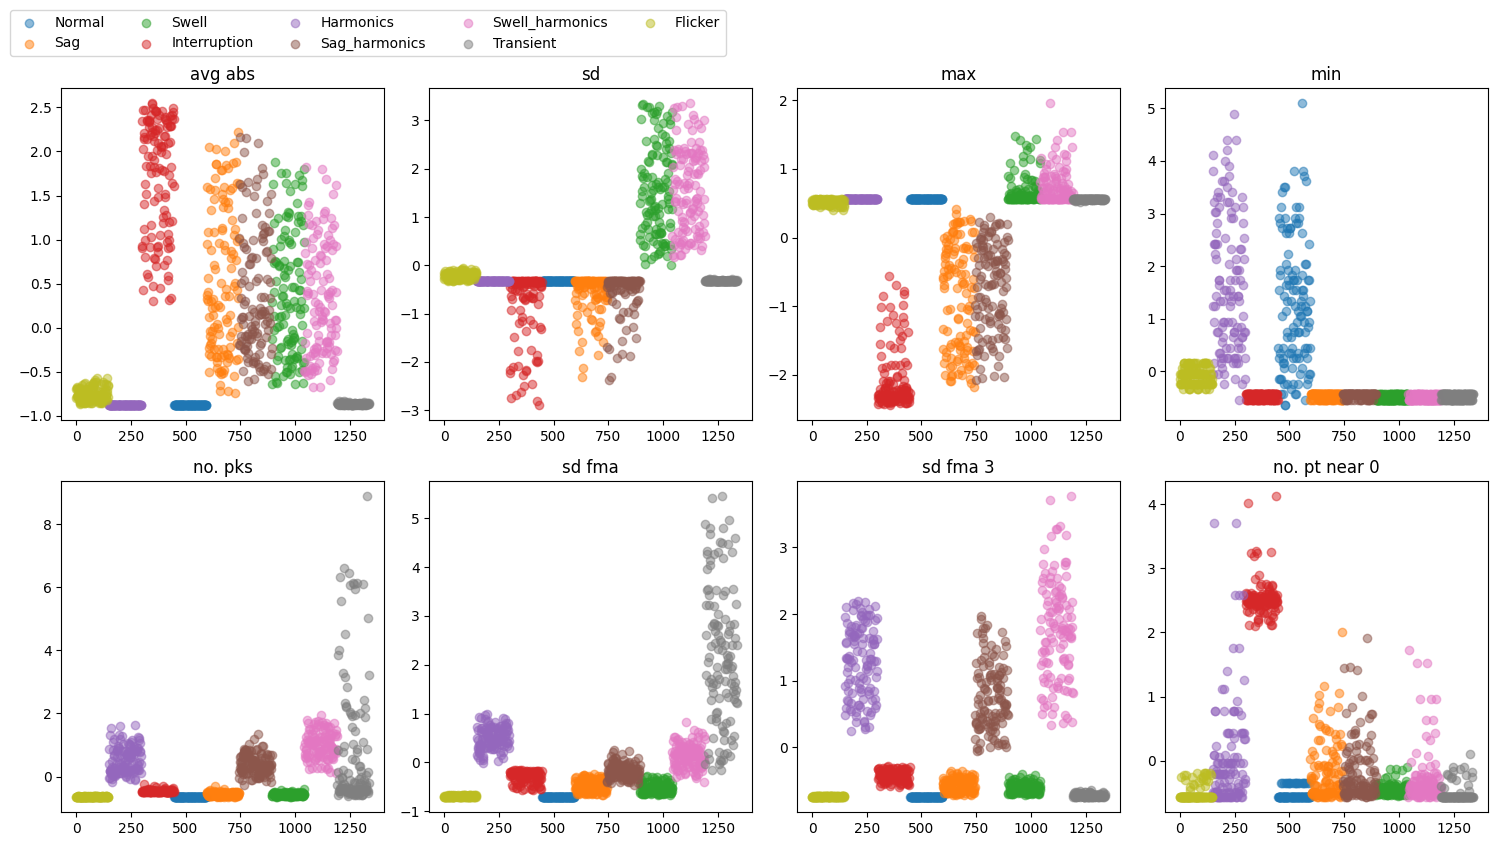

In [3]:
# 8 subplots (one for each feature): Each subplot will shows the value of the feature for each label
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(X_train_scaled.columns):
    for PQD, PQD_index in PQD_INDICES.items():
        axes[i].scatter(X_train_scaled[y_train == PQD_index].index, X_train_scaled[y_train == PQD_index][feature], alpha=0.5, label=PQD)
    axes[i].set_title(feature)

# one legend outside the subplots on the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper left', ncol=5, bbox_to_anchor=(0, 1.06))
fig.tight_layout()


In [ ]:
# Dictionary with distinguishing features for each PQD
PQD_features = { 'Normal': ['avg abs', 'min', 'sd fma 3'],
                    'Sag': ['avg abs', 'sd', 'max'],
                    'Swell': ['avg abs', 'sd', 'max'],
                    'Interruption': ['avg abs', 'max', 'no. pt near 0'],
                    'Harmonics': ['min', 'sd fma', 'sd fma 3' ],
                    'Sag_harmonics': ['avg abs', 'sd', 'sd fma 3'],
                    'Swell_harmonics': ['avg abs', 'sd', 'sd fma 3'],
                    'Transient': ['avg abs', 'sd fma', 'sd fma 3'],
                    'Flicker': ['sd fma', 'sd fma 3', 'min'],
                    }